Kreuztabelle (Anzahl):
treatment     No  Yes
remote_work          
No           444  439
Yes          178  198

Kreuztabelle (Prozent pro Remote Work):
treatment           No        Yes
remote_work                      
No           50.283126  49.716874
Yes          47.340426  52.659574

Chi2-Statistik: 0.80
p-Wert: 0.3712
Freiheitsgrade: 1
Erwartete Häufigkeiten:
[[436.23987292 446.76012708]
 [185.76012708 190.23987292]]
Cramér's V: 0.025


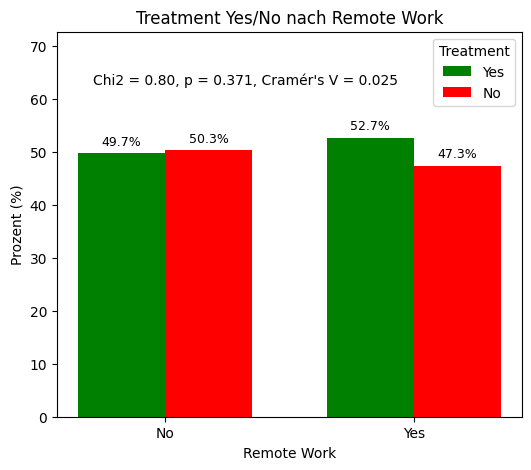

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# --- Daten einlesen ---
df = pd.read_csv("survey.csv")

# --- Treatment standardisieren ---
df['treatment'] = df['treatment'].str.strip().str.capitalize()  # Yes/No

# --- Remote Work standardisieren ---
df['remote_work'] = df['remote_work'].str.strip().str.capitalize()  # Yes/No

# --- Kreuztabelle Treatment vs Remote Work ---
ct_remote = pd.crosstab(df['remote_work'], df['treatment'])
print("Kreuztabelle (Anzahl):")
print(ct_remote)

ct_remote_percent = pd.crosstab(df['remote_work'], df['treatment'], normalize='index') * 100
print("\nKreuztabelle (Prozent pro Remote Work):")
print(ct_remote_percent)

# --- Chi-Quadrat-Test ---
chi2, p, dof, expected = chi2_contingency(ct_remote)
print(f"\nChi2-Statistik: {chi2:.2f}")
print(f"p-Wert: {p:.4f}")
print(f"Freiheitsgrade: {dof}")
print("Erwartete Häufigkeiten:")
print(expected)

# --- Effektgröße (Cramér's V) ---
n = ct_remote.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_remote.shape)-1)))
print(f"Cramér's V: {cramers_v:.3f}")

# --- Balkendiagramm mit Prozentangaben, Yes links ---
fig, ax = plt.subplots(figsize=(6,5))
width = 0.35
categories = ct_remote_percent.index.tolist()
treatments = ['Yes', 'No']  # Reihenfolge fixieren
x = range(len(categories))
colors = {"Yes": "green", "No": "red"}

for i, treatment in enumerate(treatments):
    heights = ct_remote_percent[treatment].values
    ax.bar([p + i*width for p in x], heights, width=width, label=treatment, color=colors[treatment])
    for j, h in enumerate(heights):
        ax.text(j + i*width, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9)

# --- Signifikanzannotation mittig ---
x_mitte = (0 + len(categories) - 1) / 2
y_hoch = ct_remote_percent.values.max() + 10
ax.text(x_mitte, y_hoch, 
        f"Chi2 = {chi2:.2f}, p = {p:.3f}, Cramér's V = {cramers_v:.3f}", 
        fontsize=10, ha='center')

# Achsen, Titel, Legend
ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Prozent (%)")
ax.set_xlabel("Remote Work")
ax.set_title("Treatment Yes/No nach Remote Work")
ax.set_ylim(0, ct_remote_percent.values.max() + 20)
ax.legend(title="Treatment")

plt.show()